In [1]:
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
import seaborn as sns
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import PyWGCNA
import scanpy as sc

In [2]:
data_SFA_d10f9=pd.read_csv("genes_for_metascape_from_feature9_10dims_gradient_top_bottom_5%_all.csv", header=0)
data_SFA_d10f9

,genes
0,TNMD
1,SARM1
2,ARHGAP33
3,ITGA2B
4,OSBPL7
...,...
2183,LINC02772
2184,KLHDC7B-DT
2185,GAR1-DT
2186,RBAKDN


In [3]:
data_SFA_d10f7=pd.read_csv("genes_for_metascape_from_feature7_10dims_gradient_top_bottom_5%_all.csv", header=0)
data_SFA_d10f7

,genes
0,FGR
1,HSPB6
2,CRLF1
3,YBX2
4,KRT33A
...,...
2183,JTB-DT
2184,C2orf49-DT
2185,LINC00938
2186,INSIG1-DT


In [4]:
data_SFA_d20f16=pd.read_csv("genes_for_metascape_from_feature16_20dims_gradient_top_bottom_5%_all.csv", header=0)
data_SFA_d20f16

,genes
0,THSD7A
1,TTC22
2,LGALS14
3,PROM1
4,PLEKHG6
...,...
2183,TIMMDC1-DT
2184,SLC30A6-DT
2185,ADIRF-AS1
2186,LYPD4


In [5]:
genes_10f9 = set(data_SFA_d10f9['genes'])
genes_10f7 = set(data_SFA_d10f7['genes'])

# Union: genes in either one or the other (or both)
or_genes = genes_10f9.union(genes_10f7)

# Convert to sorted list or DataFrame
or_genes_list = sorted(list(or_genes))
or_genes_df = pd.DataFrame(or_genes_list, columns=['genes'])

print(or_genes_df)



        genes
0         A2M
1        AACS
2       AADAC
3     AADACL2
4     AADACL4
...       ...
4113   ZRANB1
4114   ZSWIM8
4115     ZXDA
4116      ZYX
4117     ZZZ3

[4118 rows x 1 columns]


In [6]:
# Convert to sets for intersection
or_genes_set = set(or_genes_df['genes'])
d20f16_set = set(data_SFA_d20f16['genes'])

#Find common genes (intersection)
common_with_d20f16 = or_genes_set.intersection(d20f16_set)

# Convert to sorted list or DataFrame
common_genes_list = sorted(list(common_with_d20f16))
common_genes_df = pd.DataFrame(common_genes_list, columns=['genes'])

print(common_genes_df)


       genes
0        A2M
1    AADACL4
2      ABCB6
3      ABCC8
4       ADH4
..       ...
498     XKRX
499    ZFHX2
500     ZG16
501   ZNF322
502   ZNF761

[503 rows x 1 columns]


In [7]:
import os

In [8]:
dir_path = '/home/tfujiwara/important_data/referenced_data (reAE)/wgcna_10000_0'

# Initialize an empty set to collect all genes (for union)
all_genes = set()

# Loop through all files in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(dir_path, filename)
        
        # Read the CSV file assuming it has a 'genes' column
        df = pd.read_csv(file_path)
        
        # Add genes to the set (union)
        all_genes.update(df['gene'].dropna().unique())

# Convert set to sorted list and DataFrame
integrated_genes_list_PD = sorted(list(all_genes))
integrated_genes_df_PD = pd.DataFrame(integrated_genes_list_PD, columns=['genes'])

print(f"Total unique genes combined: {len(integrated_genes_df_PD)}")
print(integrated_genes_df_PD.head())


Total unique genes combined: 109
   genes
0   AAMP
1   ACLY
2   ACTB
3   ADD1
4  AGBL5


In [9]:
dir_path = '/home/tfujiwara/important_data/referenced_data (reAE)/wgcna_10000_1'

# Initialize an empty set to collect all genes (for union)
all_genes = set()

# Loop through all files in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(dir_path, filename)
        
        # Read the CSV file assuming it has a 'genes' column
        df = pd.read_csv(file_path)
        
        # Add genes to the set (union)
        all_genes.update(df['gene'].dropna().unique())

# Convert set to sorted list and DataFrame
integrated_genes_list_Cont = sorted(list(all_genes))
integrated_genes_df_Cont = pd.DataFrame(integrated_genes_list_Cont, columns=['genes'])

print(f"Total unique genes combined: {len(integrated_genes_df_Cont)}")
print(integrated_genes_df_Cont.head())


Total unique genes combined: 767
     genes
0     A1BG
1  AADACL2
2   ABLIM1
3      ABR
4    ACBD3


In [10]:
dir_path = '/home/tfujiwara/important_data/referenced_data (reAE)/wgcna_10000_2'

# Initialize an empty set to collect all genes (for union)
all_genes = set()

# Loop through all files in the directory
for filename in os.listdir(dir_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(dir_path, filename)
        
        # Read the CSV file assuming it has a 'genes' column
        df = pd.read_csv(file_path)
        
        # Add genes to the set (union)
        all_genes.update(df['gene'].dropna().unique())

# Convert set to sorted list and DataFrame
integrated_genes_list_HD = sorted(list(all_genes))
integrated_genes_df_HD = pd.DataFrame(integrated_genes_list_HD, columns=['genes'])

print(f"Total unique genes combined: {len(integrated_genes_df_HD)}")
print(integrated_genes_df_HD.head())


Total unique genes combined: 300
    genes
0    AAMP
1  ABI3BP
2   ADAP2
3   ADCK2
4   ADCY9


In [11]:
# Combine all genes from the three DataFrames into sets
set_PD = set(integrated_genes_df_PD['genes'])
set_Cont = set(integrated_genes_df_Cont['genes'])
set_HD = set(integrated_genes_df_HD['genes'])

# Get the union of all three sets
integrated_or_genes = set_PD.union(set_Cont).union(set_HD)

# Convert to sorted list and DataFrame
integrated_or_genes_list = sorted(list(integrated_or_genes))
integrated_or_genes_df = pd.DataFrame(integrated_or_genes_list, columns=['genes'])

print(f"Total unique genes in integrated OR list: {len(integrated_or_genes_df)}")
print(integrated_or_genes_df.head())

Total unique genes in integrated OR list: 1169
     genes
0     A1BG
1  AADACL2
2     AAMP
3   ABI3BP
4   ABLIM1


In [12]:
integrated_or_genes_df

,genes
0,A1BG
1,AADACL2
2,AAMP
3,ABI3BP
4,ABLIM1
...,...
1164,ZNF831
1165,ZNF875
1166,ZNRF3
1167,ZSWIM8


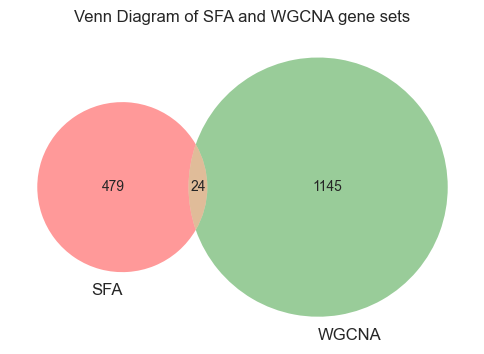

In [13]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Convert gene lists to sets
set_SFA = set(common_genes_df['genes'])
set_WGCNA = set(integrated_or_genes_df['genes'])

# Create the Venn diagram
plt.figure(figsize=(6,6))
venn = venn2([set_SFA, set_WGCNA], set_labels=('SFA', 'WGCNA'))

# Optionally customize colors, fonts etc.
plt.title("Venn Diagram of SFA and WGCNA gene sets")
plt.show()


In [14]:
# Compute overlap
overlapped_genes = sorted(set_SFA.intersection(set_WGCNA))

# Display
print(f"Total overlapping genes: {len(overlapped_genes)}")
for gene in overlapped_genes:
    print(gene)


Total overlapping genes: 24
ARHGDIB
ATP8B4
CCDC120
CCND1
CSF2RB
FGL2
GNB3
GPR183
HYPK
LINC02363
LINC02699
MC1R
MILR1
NAA50
OLFML3
OR8B8
SLC26A1
SP140
SPTBN5
STK36
SUCLG2
TEX48
TRAV23DV6
ZFHX2


In [15]:
from upsetplot import from_contents, plot
import matplotlib.pyplot as plt


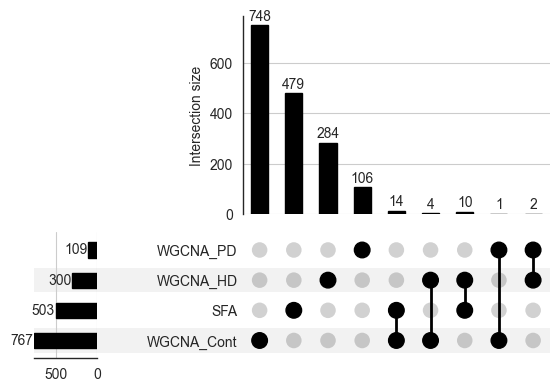

In [16]:

data = {
    'SFA': set_SFA,
    'WGCNA_PD': set_PD,
    'WGCNA_Cont': set_Cont,
    'WGCNA_HD': set_HD
}

upset_data = from_contents(data)
plot(upset_data, show_counts="{:d}")
plt.show()


In [17]:
data = {
    'SFA': set_SFA,
    'WGCNA_PD': set_PD,
    'WGCNA_Cont': set_Cont,
    'WGCNA_HD': set_HD
}

In [18]:
data

{'SFA': {'A2M',
  'AADACL4',
  'ABCB6',
  'ABCC8',
  'ADH4',
  'AHSA2P',
  'AIF1',
  'AK7',
  'ALG10',
  'ALOX5',
  'AMMECR1-IT1',
  'AP1G2',
  'ARHGAP40',
  'ARHGDIB',
  'ARL11',
  'ARMC12',
  'ART5',
  'ASCL4',
  'ATP2A1',
  'ATP2B2-IT2',
  'ATP8B4',
  'B2M',
  'B4GALNT3',
  'BARX1',
  'BLNK',
  'BTNL8',
  'C16orf92',
  'C19orf67',
  'C1QL4',
  'C1orf105',
  'C5orf60',
  'C6orf201',
  'CABP5',
  'CALML6',
  'CAPN15',
  'CARD16',
  'CARTPT',
  'CAV3',
  'CCDC120',
  'CCDC26',
  'CCDC42',
  'CCER2',
  'CCL20',
  'CCL25',
  'CCL8',
  'CCND1',
  'CCR3',
  'CD6',
  'CD79A',
  'CDCA3',
  'CDHR2',
  'CDHR4',
  'CDRT15L2',
  'CEL',
  'CEP112',
  'CEP55',
  'CGA',
  'CH25H',
  'CHAC1',
  'CHAC2',
  'CHMP4C',
  'CHRNA10',
  'CLDN10',
  'CLEC18A',
  'CLEC20A',
  'CLEC7A',
  'CLRN2',
  'CNKSR1',
  'CNTFR',
  'CPA3',
  'CPA6',
  'CPLANE2',
  'CRX',
  'CSF2RB',
  'CT45A1',
  'CTRB1',
  'CTSG',
  'CXorf49B',
  'CYP4F35P',
  'CYTL1',
  'DCAF4L1',
  'DCANP1',
  'DCDC2C',
  'DCN',
  'DDX59-AS1',
  'DE

In [19]:
set_SFA

{'A2M',
 'AADACL4',
 'ABCB6',
 'ABCC8',
 'ADH4',
 'AHSA2P',
 'AIF1',
 'AK7',
 'ALG10',
 'ALOX5',
 'AMMECR1-IT1',
 'AP1G2',
 'ARHGAP40',
 'ARHGDIB',
 'ARL11',
 'ARMC12',
 'ART5',
 'ASCL4',
 'ATP2A1',
 'ATP2B2-IT2',
 'ATP8B4',
 'B2M',
 'B4GALNT3',
 'BARX1',
 'BLNK',
 'BTNL8',
 'C16orf92',
 'C19orf67',
 'C1QL4',
 'C1orf105',
 'C5orf60',
 'C6orf201',
 'CABP5',
 'CALML6',
 'CAPN15',
 'CARD16',
 'CARTPT',
 'CAV3',
 'CCDC120',
 'CCDC26',
 'CCDC42',
 'CCER2',
 'CCL20',
 'CCL25',
 'CCL8',
 'CCND1',
 'CCR3',
 'CD6',
 'CD79A',
 'CDCA3',
 'CDHR2',
 'CDHR4',
 'CDRT15L2',
 'CEL',
 'CEP112',
 'CEP55',
 'CGA',
 'CH25H',
 'CHAC1',
 'CHAC2',
 'CHMP4C',
 'CHRNA10',
 'CLDN10',
 'CLEC18A',
 'CLEC20A',
 'CLEC7A',
 'CLRN2',
 'CNKSR1',
 'CNTFR',
 'CPA3',
 'CPA6',
 'CPLANE2',
 'CRX',
 'CSF2RB',
 'CT45A1',
 'CTRB1',
 'CTSG',
 'CXorf49B',
 'CYP4F35P',
 'CYTL1',
 'DCAF4L1',
 'DCANP1',
 'DCDC2C',
 'DCN',
 'DDX59-AS1',
 'DECR1',
 'DMBX1',
 'DMPK',
 'DMRTC1B',
 'DOCK8-AS1',
 'DPPA4',
 'DUOXA2',
 'DUXA',
 'DYNLT4',
 

In [20]:
exp_data=pd.read_csv("tpm_data.csv", header=0)
exp_data

,Unnamed: 0,ENSG,hgnc_symbol,gene_length,C_0002,C_0003,C_0004,C_0005,C_0006,C_0008,...,H_0740,H_0750,H_0513,H_0601,H_0656,H_0689,H_0709,H_0723,H_1104,H_1105
0,1,ENSG00000000003,TSPAN6,12883,2.703162,4.679815,3.827170,3.940771,3.956139,4.749555,...,4.799810,8.733498,3.666497,4.563176,2.492904,2.949728,3.314066,6.985665,3.947979,3.784485
1,2,ENSG00000000005,TNMD,14949,0.005418,0.029438,0.088121,0.036995,0.053272,0.108531,...,0.024476,0.086370,0.083015,0.078651,0.050749,0.014444,0.028001,0.138079,0.031214,0.064583
2,3,ENSG00000000419,DPM1,24273,2.625862,4.387499,4.450224,5.390720,3.707350,5.356800,...,4.100151,6.470481,5.783705,6.878268,3.167153,1.530000,6.380522,8.912018,6.420788,9.267549
3,4,ENSG00000000457,SCYL3,44636,0.896318,1.025353,1.568379,1.315815,1.617599,1.350063,...,0.610696,0.892573,1.098204,1.589228,0.708180,0.416006,0.628301,1.156094,1.317197,2.011547
4,5,ENSG00000000460,C1orf112,192073,0.033732,0.123724,0.065645,0.074862,0.063574,0.114637,...,0.030003,0.052817,0.036344,0.091820,0.025015,0.042717,0.034868,0.060181,0.072882,0.070371
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21858,26560,ENSG00000273372,SFTPD-AS1,5000,0.680299,0.616103,0.715117,1.061834,1.061811,1.437003,...,0.311009,0.202893,0.201662,1.018982,0.050577,0.647750,0.000000,0.247696,0.559947,0.096546
21859,26565,ENSG00000273396,LINC01396,6639,0.036596,0.066286,0.226767,0.049981,0.119952,0.139644,...,0.013778,0.027783,0.000000,0.000000,0.038090,0.000000,0.000000,0.000000,0.000000,0.000000
21860,26570,ENSG00000273409,LINC02712,66004,0.019632,0.040004,0.068428,0.016758,0.036196,0.017558,...,0.005544,0.027945,0.054055,0.065315,0.015325,0.009814,0.000000,0.012509,0.028278,0.058509
21861,26571,ENSG00000273415,LINC02725,87913,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [21]:
# 1. Extract rows for genes included in set_SFA (filter by 'hgnc_symbol')
filtered_data = exp_data[exp_data['hgnc_symbol'].isin(set_SFA)].copy()

# 2. Divide into 3 data frames by columns name prefix:
cont_cols = [col for col in filtered_data.columns if col.startswith('C_')]
pd_cols = [col for col in filtered_data.columns if col.startswith('P_')]
hd_cols = [col for col in filtered_data.columns if col.startswith('H_')]

df_cont = filtered_data[cont_cols]
df_pd = filtered_data[pd_cols]
df_hd = filtered_data[hd_cols]


In [22]:
import pandas as pd

# TPMデータ読み込み
tpm_df = pd.read_csv("tpm_data.csv", index_col=0)

# 有効なサンプル名（P_, C_, H_ で始まる列のみ）
sample_columns = [col for col in tpm_df.columns if col[0] in ['P', 'C', 'H']]

# スペクトラム順を決めるためのグループラベル抽出
sample_labels = [col[0] for col in sample_columns]
group_order = {'P': 2, 'C': 1, 'H': 0}
spectrum_axis = [group_order[label] for label in sample_labels]

# スペクトラム情報付きDataFrame
spectrum_df = pd.DataFrame({
    'sample': sample_columns,
    'group': sample_labels,
    'spectrum_value': spectrum_axis
})


In [23]:
# 発現行列：サンプル列のみ抽出
expression_matrix = tpm_df[spectrum_df['sample']].copy()

# 行名にHGNC symbolを使う
expression_matrix.index = tpm_df['hgnc_symbol']


In [24]:
# SFA抽出遺伝子（例として仮データ）
sfa_genes = set_SFA

# WGCNA抽出遺伝子（例）
wgcna_genes = set_WGCNA

# 各遺伝子群
sfa_only_genes = list(sfa_genes - wgcna_genes)
wgcna_only_genes = list(wgcna_genes - sfa_genes)
overlap_genes = list(sfa_genes & wgcna_genes)


In [25]:
def get_control_zscore_expression(genes, expr_mat, spectrum_df):
    subset = expr_mat.loc[expr_mat.index.intersection(genes)]
    if subset.empty:
        return None

    # Control 群のサンプルを抽出
    control_samples = spectrum_df[spectrum_df["group"] == "C"]["sample"].values
    control_expr = subset[control_samples]

    # 各遺伝子ごとの μ, σ（Control 基準）を計算
    mean_ctrl = control_expr.mean(axis=1)
    std_ctrl = control_expr.std(axis=1)

    # 全サンプルに対して Z-score 変換（Controlを基準）
    zscore_df = (subset.subtract(mean_ctrl, axis=0)).divide(std_ctrl, axis=0)
    return zscore_df

# 各遺伝子群について Control基準でZスコア標準化
expr_sfa = get_control_zscore_expression(sfa_only_genes, expression_matrix, spectrum_df)
expr_wgcna = get_control_zscore_expression(wgcna_only_genes, expression_matrix, spectrum_df)
expr_overlap = get_control_zscore_expression(overlap_genes, expression_matrix, spectrum_df)

# スペクトラム順にサンプルを並び替え
ordered_samples = spectrum_df.sort_values("spectrum_value")["sample"].values
if expr_sfa is not None:
    expr_sfa = expr_sfa[ordered_samples]
if expr_wgcna is not None:
    expr_wgcna = expr_wgcna[ordered_samples]
if expr_overlap is not None:
    expr_overlap = expr_overlap[ordered_samples]


In [26]:
# サンプル名をスペクトラム順に並べ替え
ordered_samples = spectrum_df.sort_values("spectrum_value")["sample"].values

# 各行列の列をスペクトラム順に並び替え
expr_sfa = expr_sfa[ordered_samples]
expr_wgcna = expr_wgcna[ordered_samples]
expr_overlap = expr_overlap[ordered_samples]


In [27]:
# Setごとに "Set" 列を付けて DataFrame 化
expr_sfa_df = expr_sfa.copy()
expr_sfa_df["Set"] = "SFA-only"
expr_sfa_df["Set2"] = "0_SFA-only"

expr_wgcna_df = expr_wgcna.copy()
expr_wgcna_df["Set"] = "WGCNA-only"
expr_wgcna_df["Set2"] = "2_WGCNA-only"

expr_overlap_df = expr_overlap.copy()
expr_overlap_df["Set"] = "Overlap"
expr_overlap_df["Set2"] = "1_Overlap"

# 行を結合（index: gene symbol）
expr_all = pd.concat([expr_sfa_df,  expr_overlap_df,expr_wgcna_df,])

# Setで並び替え（描画順が SFA → WGCNA → Overlap）
expr_all = expr_all.sort_values("Set2")

# 行名を gene (Set) 形式にして重複を避ける
expr_all["GeneID"] = expr_all.index
expr_all.index = expr_all["GeneID"] + " (" + expr_all["Set"] + ")"



In [28]:
# サンプルの group 情報
sample_to_group = spectrum_df.set_index("sample")["group"]

# 数値データだけ抽出（サンプル列のみ）
sample_cols = [col for col in expr_all.columns if col in sample_to_group.index]
expr_numeric = expr_all[sample_cols].copy()

# orientation 用の関数
def orient_gene(row):
    group_means = row.groupby(sample_to_group).mean()
    hd_mean = group_means.get("H", 0)
    # cp_max = max(group_means.get("C", 0), group_means.get("P", 0))
    # return row * (1 if hd_mean >= cp_max else -1)
    p_mean = group_means.get("P", 0)
    return row * (1 if hd_mean >= p_mean else -1)

# 全行に適用（符号修正）
expr_signed = expr_numeric.apply(orient_gene, axis=1)

# メタ情報を付け直す
expr_signed["Set"] = expr_all["Set"]
expr_signed["Set2"] = expr_all["Set2"]
expr_signed["GeneID"] = expr_all.index  # 元の index は gene symbol

# Setで並び替え
expr_signed = expr_signed.sort_values("Set2")

# ヒートマップ用のデータだけ抽出
heatmap_matrix_signed = expr_signed[ordered_samples]



In [29]:
ordered_samples

array(['H_1105', 'H_0001', 'H_0002', 'H_0003', 'H_0005', 'H_0006',
       'H_0007', 'H_0009', 'H_0010', 'H_0012', 'H_0013', 'H_0014',
       'H_0539', 'H_0657', 'H_0008', 'H_0681', 'H_0658', 'H_0723',
       'H_0709', 'H_0689', 'H_0656', 'H_0601', 'H_1104', 'H_0750',
       'H_0740', 'H_0726', 'H_0700', 'H_0695', 'H_0513', 'C_0031',
       'C_0032', 'C_0033', 'C_0034', 'C_0035', 'C_0036', 'C_0050',
       'C_0038', 'C_0039', 'C_0053', 'C_0070', 'C_0077', 'C_0037',
       'C_0087', 'C_0002', 'C_0075', 'C_0022', 'C_0023', 'C_0024',
       'C_0025', 'C_0026', 'C_0029', 'C_0021', 'C_0060', 'C_0083',
       'C_0082', 'C_0081', 'C_0076', 'C_0062', 'C_0071', 'C_0061',
       'C_0069', 'C_0020', 'C_0018', 'C_0003', 'C_0004', 'C_0005',
       'C_0006', 'C_0008', 'C_0009', 'C_0019', 'C_0010', 'C_0012',
       'C_0013', 'C_0014', 'C_0015', 'C_0016', 'C_0017', 'C_0011',
       'C_0065', 'P_0019', 'P_0003', 'P_0020', 'P_0021', 'P_0022',
       'P_0023', 'P_0026', 'P_0027', 'P_0028', 'P_0029', 'P_00

In [30]:
expr_signed 

,H_1105,H_0001,H_0002,H_0003,H_0005,H_0006,H_0007,H_0009,H_0010,H_0012,...,P_0015,P_0014,P_0013,P_0012,P_0006,P_0018,P_0030,Set,Set2,GeneID
OSBPL7 (SFA-only),-0.084667,-0.843144,0.889108,-1.116399,0.268667,-0.529078,-0.922274,0.904506,0.069179,0.766413,...,-0.817773,-0.783396,-1.123815,0.033062,0.297889,-0.339832,-1.648573,SFA-only,0_SFA-only,OSBPL7 (SFA-only)
GSDMB (SFA-only),0.281605,-0.946012,0.522314,-1.513006,-0.117586,-0.062804,-1.430550,-0.428075,0.000735,-0.525631,...,-0.162039,-0.218275,0.230466,-0.102720,-0.184876,-0.545436,-1.678378,SFA-only,0_SFA-only,GSDMB (SFA-only)
GSTA5 (SFA-only),0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,...,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,0.141421,SFA-only,0_SFA-only,GSTA5 (SFA-only)
ABCC8 (SFA-only),-0.052069,0.294391,1.054860,0.835965,0.522538,0.533091,0.131936,0.739719,-0.182308,0.686974,...,0.596575,0.191976,-0.150178,0.049779,0.831432,0.549737,-0.238762,SFA-only,0_SFA-only,ABCC8 (SFA-only)
IL32 (SFA-only),-3.871524,0.427793,0.486452,-1.069589,1.744806,-1.774708,-0.555792,-1.393929,0.492276,-0.488344,...,0.751383,1.496393,0.220912,0.343140,-1.219275,-0.226217,-0.359913,SFA-only,0_SFA-only,IL32 (SFA-only)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LSP1P1 (WGCNA-only),-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,...,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,-0.273833,WGCNA-only,2_WGCNA-only,LSP1P1 (WGCNA-only)
LINC00221 (WGCNA-only),-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,...,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,-0.164792,WGCNA-only,2_WGCNA-only,LINC00221 (WGCNA-only)
UGT2A2 (WGCNA-only),-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,...,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,-0.141421,WGCNA-only,2_WGCNA-only,UGT2A2 (WGCNA-only)
RNFT1-DT (WGCNA-only),3.718524,-0.481236,-1.023004,0.139146,0.326134,-0.068265,2.307084,0.310205,-0.042573,-0.912206,...,-0.758158,0.226150,-0.206664,0.782199,-0.571710,-0.941783,-0.796006,WGCNA-only,2_WGCNA-only,RNFT1-DT (WGCNA-only)


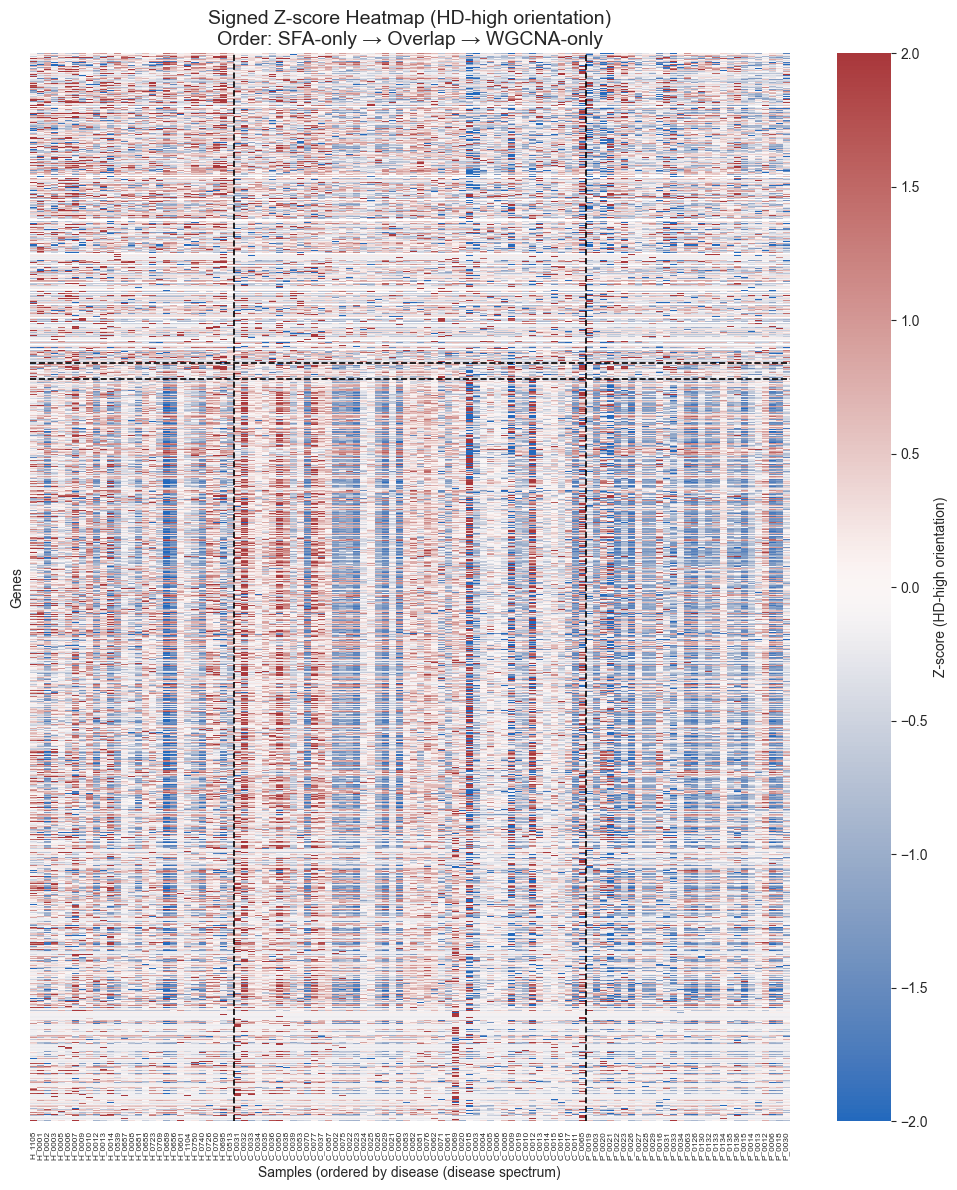

In [31]:
# サンプルの group 情報をスペクトラム順に並べる
sample_groups_ordered = spectrum_df.set_index("sample").loc[ordered_samples]["group"].values

# P, C, H の切れ目のインデックスを取得（縦線を入れる位置）
group_boundaries = []
for i in range(1, len(sample_groups_ordered)):
    if sample_groups_ordered[i] != sample_groups_ordered[i - 1]:
        group_boundaries.append(i)

# 横の区切り線：Setごとの境界
set_counts = expr_signed["Set"].value_counts().loc[["SFA-only", "Overlap", "WGCNA-only"]]
row_boundaries = set_counts.cumsum().values[:-1]
        
plt.figure(figsize=(10, min(0.3 * heatmap_matrix_signed.shape[0], 12)))
ax = sns.heatmap(
    heatmap_matrix_signed,
    cmap="vlag",
    center=0,
    vmin=-2,
    vmax=2,
    cbar_kws={"label": "Z-score (HD-high orientation)"},
    yticklabels=False,
    xticklabels=ordered_samples  # サンプルIDを表示
)

# 横線（Set区切り）
for y in row_boundaries:
    ax.hlines(y, *ax.get_xlim(), color='black', linestyle='--', linewidth=1.2)

# 縦線（PD / C / HDの切れ目）
for x in group_boundaries:
    ax.vlines(x, *ax.get_ylim(), color='black', linestyle='--', linewidth=1.2)

# サンプルIDの表示調整（回転・フォントサイズ）
ax.set_xticklabels(ordered_samples, rotation=90, fontsize=6)

plt.title("Signed Z-score Heatmap (HD-high orientation)\nOrder: SFA-only → Overlap → WGCNA-only", fontsize=14)
plt.xlabel("Samples (ordered by disease (disease spectrum)")
plt.ylabel("Genes")
plt.tight_layout()
plt.show()


In [32]:
# サンプルグループ辞書（sample名 → group: H, C, P）
sample_to_group = spectrum_df.set_index("sample")["group"].to_dict()

# 対象群
groups = ["H", "C", "P"]
sets = ["SFA-only", "Overlap", "WGCNA-only"]

# 平均±SEの表を作る
summary_data = []

for set_name in sets:
    # 対象セットのデータ
    subset = expr_signed[expr_signed["Set"] == set_name]
    values = subset[ordered_samples]  # Zスコア部分のみ

    # 不正な値を含む行（遺伝子）を除外
    values_clean = values[~values.isin([np.inf, -np.inf]).any(axis=1)]
    values_clean = values_clean.dropna(how="any")

    row = {}
    for group in groups:
        group_samples = [s for s in ordered_samples if sample_to_group.get(s) == group]
        if not group_samples:
            row[group] = "NA"
            continue

        z_vals = values_clean[group_samples].values.flatten()
        mean = np.mean(z_vals)
        se = np.std(z_vals, ddof=1) / np.sqrt(len(z_vals))
        row[group] = f"{mean:.2f} ± {se:.2f}"

    summary_data.append(row)

# DataFrameとして出力
summary_df = pd.DataFrame(summary_data, index=sets)
summary_df.columns = ["HD", "Control", "PD"]
summary_df.index.name = "Set"

# 表示
print(summary_df)


                      HD       Control            PD
Set                                                 
SFA-only     0.53 ± 0.15   0.00 ± 0.01  -0.14 ± 0.02
Overlap      0.37 ± 0.06  -0.00 ± 0.03  -0.04 ± 0.04
WGCNA-only  -0.01 ± 0.01   0.00 ± 0.00  -0.28 ± 0.01


In [33]:
!jupyter nbconvert --to html Public_PD_HD_SFAgene_vs_WGCNAgene-withPlots.ipynb

[NbConvertApp] Converting notebook Public_PD_HD_SFAgene_vs_WGCNAgene-withPlots.ipynb to html
[NbConvertApp] Writing 1409187 bytes to Public_PD_HD_SFAgene_vs_WGCNAgene-withPlots.html
